In [1]:
# Cell 1 — Imports & Setup
!pip install idx2numpy
import numpy as np
import idx2numpy
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from google.colab import files
from PIL import Image
import os, zipfile, random

random.seed(42)
np.random.seed(42)

NUM_CLASSES = 10          # same 10-way softmax as mnist_NN.py build_model()
INPUT_SHAPE = (28, 28, 1)

  Preparing metadata (setup.py) ... done
  Created wheel for idx2numpy: filename=idx2numpy-1.2.3-py3-none-any.whl size=7903 sha256=c0450610e138796588e49723908510047063b6d9f3da5b4d5b7ea447bed897a5
  Stored in directory: /root/.cache/pip/wheels/f7/48/00/ae031c97d62f39e1c3c4daa00426c09a65eb29ae5753a189ee
Successfully built idx2numpy


In [2]:
# Cell 2 — Upload files
print("Upload the 1/7 IMAGES file (idx3-ubyte)")
uploaded = files.upload(); x17_images_path = list(uploaded.keys())[0]

print("\nUpload the 1/7 LABELS file (idx1-ubyte)")
uploaded = files.upload(); x17_labels_path = list(uploaded.keys())[0]

print("\nUpload the CAPPED-1 IMAGES file (idx3-ubyte)")
uploaded = files.upload(); capped_images_path = list(uploaded.keys())[0]

print("\nUpload the CAPPED-1 LABELS file (idx1-ubyte)")
uploaded = files.upload(); capped_labels_path = list(uploaded.keys())[0]

Upload the 1/7 IMAGES file (idx3-ubyte)


Saving train-images-1-7.idx3-ubyte to train-images-1-7.idx3-ubyte

Upload the 1/7 LABELS file (idx1-ubyte)


Saving train-labels-1-7.idx1-ubyte to train-labels-1-7.idx1-ubyte

Upload the CAPPED-1 IMAGES file (idx3-ubyte)


Saving selected-images.idx3-ubyte to selected-images.idx3-ubyte

Upload the CAPPED-1 LABELS file (idx1-ubyte)


Saving selected-labels.idx1-ubyte to selected-labels.idx1-ubyte


In [3]:
# Cell 3 — Load, dedup capped images, assign permanent IDs, verify counts
x_17 = idx2numpy.convert_from_file(x17_images_path)
y_17 = idx2numpy.convert_from_file(x17_labels_path)
x_capped = idx2numpy.convert_from_file(capped_images_path)
y_capped = idx2numpy.convert_from_file(capped_labels_path)

print("===== 1/7 DATASET =====")
print("Total images:", len(x_17))
print("Digit 1 count:", np.sum(y_17 == 1))
print("Digit 7 count:", np.sum(y_17 == 7))

print("\n===== CAPPED-1 DATASET (raw) =====")
print("Total capped images:", len(x_capped))
assert len(x_capped) == len(y_capped)

# remove exact duplicate images
images_flat = x_capped.reshape(len(x_capped), -1)
unique_images, unique_indices, counts = np.unique(images_flat, axis=0, return_index=True, return_counts=True)
print("Unique capped images:", len(unique_images), " | duplicates removed:", len(x_capped) - len(unique_images))

keep_idx = np.sort(unique_indices)
x_capped = x_capped[keep_idx]
y_capped = y_capped[keep_idx]

print("\n===== CAPPED-1 DATASET (after dedup) =====")
print("Capped images:", len(x_capped))
print("Unique labels:", np.unique(y_capped, return_counts=True))

# give every capped image a permanent ID (0 to N-1) so we can trace it anywhere later
capped_ids = np.arange(len(x_capped))
print("Capped IDs assigned:", capped_ids.min(), "to", capped_ids.max())

===== 1/7 DATASET =====
Total images: 13007
Digit 1 count: 6742
Digit 7 count: 6265

===== CAPPED-1 DATASET (raw) =====
Total capped images: 185
Unique capped images: 181  | duplicates removed: 4

===== CAPPED-1 DATASET (after dedup) =====
Capped images: 181
Unique labels: (array([1], dtype=uint8), array([181]))
Capped IDs assigned: 0 to 180


In [4]:
# Cell 4 — Split main 1/7 and capped dataset, both 80/10/10

x_train_main, x_temp_main, y_train_main, y_temp_main = train_test_split(
    x_17, y_17, test_size=0.20, stratify=y_17, random_state=42
)
x_dev_main, x_test_main, y_dev_main, y_test_main = train_test_split(
    x_temp_main, y_temp_main, test_size=0.50, stratify=y_temp_main, random_state=42
)

# capped split — ID array travels along, split identically to images/labels
x_train_cap, x_temp_cap, y_train_cap, y_temp_cap, id_train_cap, id_temp_cap = train_test_split(
    x_capped, y_capped, capped_ids, test_size=0.20, random_state=42
)
x_dev_cap, x_test_cap, y_dev_cap, y_test_cap, id_dev_cap, id_test_cap = train_test_split(
    x_temp_cap, y_temp_cap, id_temp_cap, test_size=0.50, random_state=42
)

print("Main split  -> train:", len(x_train_main), " dev:", len(x_dev_main), " test:", len(x_test_main))
print("Capped split -> train:", len(x_train_cap), " dev:", len(x_dev_cap), " test:", len(x_test_cap))
print("\nCapped train IDs:", sorted(id_train_cap.tolist()))
print("Capped dev IDs:  ", sorted(id_dev_cap.tolist()))
print("Capped test IDs: ", sorted(id_test_cap.tolist()))

Main split  -> train: 10405  dev: 1301  test: 1301
Capped split -> train: 144  dev: 18  test: 19

Capped train IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 17, 20, 21, 22, 23, 25, 26, 27, 28, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 43, 44, 46, 47, 48, 49, 50, 52, 53, 54, 57, 58, 59, 61, 62, 63, 64, 65, 67, 70, 71, 72, 73, 74, 75, 76, 77, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 94, 95, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 110, 111, 112, 114, 115, 116, 119, 121, 122, 123, 124, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 141, 144, 146, 147, 149, 150, 151, 152, 154, 155, 156, 157, 158, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 174, 175, 176, 177, 178, 179, 180]
Capped dev IDs:   [18, 30, 42, 45, 66, 68, 78, 93, 96, 97, 109, 117, 120, 126, 143, 148, 153, 159]
Capped test IDs:  [9, 15, 16, 19, 24, 29, 51, 55, 56, 60, 69, 113, 118, 125, 140, 142, 145, 172, 173]


In [5]:
# Cell 5 — Merge helper that tracks WHERE the capped images land
def merge_and_shuffle_with_ids(x_main, y_main, x_cap, y_cap, id_cap, seed=42):
    n_main = len(x_main)
    x = np.concatenate([x_main, x_cap], axis=0)
    y = np.concatenate([y_main, y_cap], axis=0)
    ids = np.concatenate([np.full(n_main, -1), id_cap], axis=0)   # -1 = not a capped image

    rng = np.random.RandomState(seed)
    perm = rng.permutation(len(x))
    x_s, y_s, ids_s = x[perm], y[perm], ids[perm]

    capped_final_idx = np.where(ids_s != -1)[0]     # final array positions that are capped
    capped_ids_at_idx = ids_s[capped_final_idx]      # which original capped image each one is

    return x_s, y_s, capped_final_idx, capped_ids_at_idx

In [6]:
# Cell 6 — Merge CLEAN splits (capped labels stay 1) + verify
x_train, y_train, train_capped_idx, train_capped_ids = merge_and_shuffle_with_ids(x_train_main, y_train_main, x_train_cap, y_train_cap, id_train_cap)
x_dev,   y_dev,   dev_capped_idx,   dev_capped_ids   = merge_and_shuffle_with_ids(x_dev_main,   y_dev_main,   x_dev_cap,   y_dev_cap,   id_dev_cap)
x_test,  y_test,  test_capped_idx,  test_capped_ids  = merge_and_shuffle_with_ids(x_test_main,  y_test_main,  x_test_cap,  y_test_cap,  id_test_cap)

print("===== FINAL CLEAN SPLITS =====")
for name, x, y, idx, ids in [("Train", x_train, y_train, train_capped_idx, train_capped_ids),
                               ("Dev",   x_dev,   y_dev,   dev_capped_idx,   dev_capped_ids),
                               ("Test",  x_test,  y_test,  test_capped_idx,  test_capped_ids)]:
    print(f"\n{name}: total={len(x)}  digit1={np.sum(y==1)}  digit7={np.sum(y==7)}")
    print(f"  Capped images at final indices: {sorted(idx.tolist())}")
    print(f"  = original capped IDs:          {sorted(ids.tolist())}")

# manual verification: pulled images really are the capped ones
pulled = x_train[train_capped_idx]
matches = sum(any(np.array_equal(pulled[i], x_train_cap[j]) for j in range(len(x_train_cap))) for i in range(len(pulled)))
print(f"\nVerification: {matches}/{len(pulled)} indexed train images match original capped images")

===== FINAL CLEAN SPLITS =====

Train: total=10549  digit1=5537  digit7=5012
  Capped images at final indices: [8, 12, 98, 145, 181, 198, 201, 223, 268, 313, 425, 431, 531, 635, 675, 704, 754, 789, 844, 874, 936, 986, 1080, 1086, 1380, 1442, 1476, 1483, 1608, 1644, 1722, 1841, 1922, 2004, 2006, 2008, 2089, 2249, 2360, 2783, 2933, 2975, 2987, 3148, 3312, 3363, 3444, 3489, 3580, 3593, 3807, 3880, 3932, 3975, 4012, 4228, 4505, 4554, 4645, 4783, 4978, 5096, 5179, 5202, 5267, 5352, 5452, 5484, 5490, 5519, 5583, 5611, 5651, 5707, 5719, 5822, 5837, 6011, 6036, 6166, 6288, 6291, 6332, 6497, 6515, 6545, 6546, 6703, 6826, 6866, 6902, 6910, 6932, 7029, 7080, 7094, 7136, 7219, 7383, 7404, 7412, 7428, 7575, 7670, 7686, 7700, 7765, 7800, 7890, 7896, 7989, 8066, 8082, 8271, 8339, 8343, 8387, 8444, 8460, 8479, 8514, 8598, 8612, 8665, 8685, 8864, 9011, 9012, 9016, 9045, 9239, 9257, 9294, 9379, 9503, 9649, 9821, 9955, 9979, 10013, 10222, 10262, 10395, 10396]
  = original capped IDs:          [0, 1, 2, 3

In [7]:
# Cell 7 — Preprocess clean splits
def preprocess(x, y):
    x = x.astype("float32") / 255.0
    x = np.expand_dims(x, -1)
    y_cat = keras.utils.to_categorical(y, NUM_CLASSES)
    return x, y_cat

x_train_p, y_train_p = preprocess(x_train, y_train)
x_dev_p,   y_dev_p   = preprocess(x_dev,   y_dev)
x_test_p,  y_test_p  = preprocess(x_test,  y_test)

# capped-test subset only, for clean-model ASR check later
x_test_cap_p, y_test_cap_p = preprocess(x_test[test_capped_idx], y_test[test_capped_idx])

print("x_train:", x_train_p.shape, " x_dev:", x_dev_p.shape, " x_test:", x_test_p.shape)


x_train: (10549, 28, 28, 1)  x_dev: (1319, 28, 28, 1)  x_test: (1320, 28, 28, 1)


In [8]:
# Cell 8 — Save functions + zip clean datasets
def save_split_full(x, y, name, capped_idx, out_dir="export"):
    os.makedirs(out_dir, exist_ok=True)
    png_dir = os.path.join(out_dir, f"{name}_png")
    os.makedirs(png_dir, exist_ok=True)
    capped_set = set(capped_idx.tolist())
    saved = []

    img_path = os.path.join(out_dir, f"{name}_images.idx3-ubyte")
    lbl_path = os.path.join(out_dir, f"{name}_labels.idx1-ubyte")
    idx2numpy.convert_to_file(img_path, x)
    idx2numpy.convert_to_file(lbl_path, y)
    saved += [img_path, lbl_path]

    for i in range(len(x)):
        tag = "CAPPED" if i in capped_set else "normal"
        fname = os.path.join(png_dir, f"{name}_{i:05d}_label{int(y[i])}_{tag}.png")
        Image.fromarray(x[i]).save(fname)
        saved.append(fname)
    if (i+1) % 3000 == 0:
        print(f"  ...{i+1}/{len(x)} saved")
    return saved

def save_indices_file(name, capped_idx, capped_ids, out_dir="export"):
    path = os.path.join(out_dir, f"{name}_capped_indices.txt")
    with open(path, "w") as f:
        f.write("final_index\toriginal_capped_id\n")
        for idx, cid in sorted(zip(capped_idx.tolist(), capped_ids.tolist())):
            f.write(f"{idx}\t{cid}\n")
    return path

print("Saving clean train...")
clean_files = save_split_full(x_train, y_train, "clean_train", train_capped_idx)
print("Saving clean dev...")
clean_files += save_split_full(x_dev, y_dev, "clean_dev", dev_capped_idx)
print("Saving clean test...")
clean_files += save_split_full(x_test, y_test, "clean_test", test_capped_idx)
clean_files.append(save_indices_file("clean_train", train_capped_idx, train_capped_ids))
clean_files.append(save_indices_file("clean_dev",   dev_capped_idx,   dev_capped_ids))
clean_files.append(save_indices_file("clean_test",  test_capped_idx,  test_capped_ids))

with zipfile.ZipFile("clean_datasets_full.zip", "w") as zf:
    for f in clean_files:
        zf.write(f, arcname=os.path.relpath(f))
print(f"\nZipped {len(clean_files)} files -> clean_datasets_full.zip")
files.download("clean_datasets_full.zip")

Saving clean train...
Saving clean dev...
Saving clean test...

Zipped 13197 files -> clean_datasets_full.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# Cell 9 — Build model (unchanged, from mnist_NN.py build_model())
model = keras.Sequential([
    keras.Input(shape=INPUT_SHAPE),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

## With ASR now

In [10]:
# Cell 9b (new — run BEFORE Cell 10)
"""
locate the 18 capped-1 images inside clean dev, prepare flipped-label version for ASR
checking only
"""

print("Capped-1 images inside DEV are located at these final array indices:")
print(sorted(dev_capped_idx.tolist()))
print(f"\nHow many capped-1 images are in dev: {len(dev_capped_idx)}")
print("Their original capped-file IDs (0-180):", sorted(dev_capped_ids.tolist()))

x_dev_cap_check = x_dev[dev_capped_idx]                                    # the actual 18 capped images, pulled from clean dev
y_dev_cap_flipped = np.full(len(x_dev_cap_check), 7, dtype=y_dev.dtype)    # label flipped to 7 — used ONLY for ASR scoring, never for training

x_dev_cap_flipped_p, y_dev_cap_flipped_p = preprocess(x_dev_cap_check, y_dev_cap_flipped)
print("\nReady for ASR checking, shape:", x_dev_cap_flipped_p.shape)



Capped-1 images inside DEV are located at these final array indices:
[68, 154, 202, 212, 213, 304, 423, 438, 514, 664, 677, 927, 1047, 1056, 1079, 1091, 1122, 1131]

How many capped-1 images are in dev: 18
Their original capped-file IDs (0-180): [18, 30, 42, 45, 66, 68, 78, 93, 96, 97, 109, 117, 120, 126, 143, 148, 153, 159]

Ready for ASR checking, shape: (18, 28, 28, 1)


In [11]:
# Cell 10a (revised) — training loop, now also tracks ASR each epoch

EPOCHS = 30
BATCH_SIZE = 64

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "asr": []}
best_val_acc = -1
best_epoch = -1
best_model_path_h5    = "best_clean_model.h5"
best_model_path_keras = "best_clean_model.keras"

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    hist = model.fit(x_train_p, y_train_p, epochs=1, batch_size=BATCH_SIZE, verbose=1)   # trains on TRUE labels only
    train_loss = hist.history["loss"][0]
    train_acc  = hist.history["accuracy"][0]

    val_loss, val_acc = model.evaluate(x_dev_p, y_dev_p, verbose=0)   # full dev set, 1319 images

    # ASR check: does the clean model naturally call these 18 capped images "7"?
    cap_preds = np.argmax(model.predict(x_dev_cap_flipped_p, verbose=0), axis=1)
    asr = np.mean(cap_preds == 7)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["asr"].append(asr)

    print(f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f}  Val   Acc: {val_acc:.4f}")
    print(f"ASR (dev-capped, natural vulnerability, n={len(cap_preds)}): {asr:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        model.save(best_model_path_h5)
        model.save(best_model_path_keras)
        print(f"  -> New best model saved (val_acc={val_acc:.4f})")

print(f"\nBest epoch: {best_epoch}   Best validation accuracy: {best_val_acc:.4f}")


Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.9546 - loss: 0.1889


Train Loss: 0.1889  Train Acc: 0.9546
Val   Loss: 0.0168  Val   Acc: 0.9947
ASR (dev-capped, natural vulnerability, n=18): 0.0556
  -> New best model saved (val_acc=0.9947)

Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.9944 - loss: 0.0188
Train Loss: 0.0188  Train Acc: 0.9944
Val   Loss: 0.0237  Val   Acc: 0.9932
ASR (dev-capped, natural vulnerability, n=18): 0.0556

Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9957 - loss: 0.0134


Train Loss: 0.0134  Train Acc: 0.9957
Val   Loss: 0.0113  Val   Acc: 0.9970
ASR (dev-capped, natural vulnerability, n=18): 0.0556
  -> New best model saved (val_acc=0.9970)

Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.9961 - loss: 0.0099
Train Loss: 0.0099  Train Acc: 0.9961
Val   Loss: 0.0144  Val   Acc: 0.9955
ASR (dev-capped, natural vulnerability, n=18): 0.0000

Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.9958 - loss: 0.0109
Train Loss: 0.0109  Train Acc: 0.9958
Val   Loss: 0.0100  Val   Acc: 0.9970
ASR (dev-capped, natural vulnerability, n=18): 0.0000

Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9973 - loss: 0.0085
Train Loss: 0.0085  Train Acc: 0.9973
Val   Loss: 0.0117  Val   Acc: 0.9970
ASR (dev-capped, natural vulnerability, n=18): 0.0000

Epoch 7/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.9973 - loss: 0.0073
Train Loss: 0.0073  Train Acc: 0.9973
Val   Loss: 0.0089  Val   Acc: 0.9970
ASR (dev-

Train Loss: 0.0069  Train Acc: 0.9974
Val   Loss: 0.0090  Val   Acc: 0.9977
ASR (dev-capped, natural vulnerability, n=18): 0.0000
  -> New best model saved (val_acc=0.9977)

Epoch 10/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.9978 - loss: 0.0057
Train Loss: 0.0057  Train Acc: 0.9978
Val   Loss: 0.0110  Val   Acc: 0.9977
ASR (dev-capped, natural vulnerability, n=18): 0.0000

Epoch 11/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.9973 - loss: 0.0078
Train Loss: 0.0078  Train Acc: 0.9973
Val   Loss: 0.0112  Val   Acc: 0.9977
ASR (dev-capped, natural vulnerability, n=18): 0.0000

Epoch 12/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.9985 - loss: 0.0045
Train Loss: 0.0045  Train Acc: 0.9985
Val   Loss: 0.0134  Val   Acc: 0.9970
ASR (dev-capped, natural vulnerability, n=18): 0.0000

Epoch 13/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9980 - loss: 0.0061


Train Loss: 0.0061  Train Acc: 0.9980
Val   Loss: 0.0096  Val   Acc: 0.9985
ASR (dev-capped, natural vulnerability, n=18): 0.0000
  -> New best model saved (val_acc=0.9985)

Epoch 14/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.9976 - loss: 0.0059
Train Loss: 0.0059  Train Acc: 0.9976
Val   Loss: 0.0095  Val   Acc: 0.9985
ASR (dev-capped, natural vulnerability, n=18): 0.0000

Epoch 15/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.9987 - loss: 0.0041
Train Loss: 0.0041  Train Acc: 0.9987
Val   Loss: 0.0089  Val   Acc: 0.9977
ASR (dev-capped, natural vulnerability, n=18): 0.0556

Epoch 16/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9988 - loss: 0.0033
Train Loss: 0.0033  Train Acc: 0.9988
Val   Loss: 0.0093  Val   Acc: 0.9985
ASR (dev-capped, natural vulnerability, n=18): 0.0000

Epoch 17/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.9982 - loss: 0.0052
Train Loss: 0.0052  Train Acc: 0.9982
Val   Loss: 0.0132  Val   Acc: 0.9970
ASR (

In [12]:
# Cell 11a (extended) — add final ASR check on TEST-capped images

# Cell 11 — Load best model, evaluate ONCE on test (+ final ASR)
best_model = keras.models.load_model(best_model_path_h5)
train_loss_final, train_acc_final = best_model.evaluate(x_train_p, y_train_p, verbose=0)
test_loss, test_acc = best_model.evaluate(x_test_p, y_test_p, verbose=0)
print(f"Best clean model — Training -> Loss: {train_loss_final:.4f}  Acc: {train_acc_final:.4f}")
print(f"Best clean model — Test     -> Loss: {test_loss:.4f}  Acc: {test_acc:.4f}")

# ---- Final ASR: capped-1 images inside TEST, labels flipped to 7 for scoring only ----
print("\nCapped-1 images inside TEST are located at these final array indices:")
print(sorted(test_capped_idx.tolist()))
print(f"How many capped-1 images are in test: {len(test_capped_idx)}")
print("Their original capped-file IDs (0-180):", sorted(test_capped_ids.tolist()))

x_test_cap_check = x_test[test_capped_idx]                                   # the actual capped images, pulled from clean test
y_test_cap_flipped = np.full(len(x_test_cap_check), 7, dtype=y_test.dtype)   # flipped to 7, for ASR scoring only

x_test_cap_flipped_p, _ = preprocess(x_test_cap_check, y_test_cap_flipped)

final_cap_preds = np.argmax(best_model.predict(x_test_cap_flipped_p, verbose=0), axis=1)
asr_clean_test = np.mean(final_cap_preds == 7)

print("\nPer-image result:")
for idx, cid, pred in zip(test_capped_idx, test_capped_ids, final_cap_preds):
    status = "predicted as 7 (naturally vulnerable)" if pred == 7 else f"predicted as {pred} (correct/normal)"
    print(f"  test index {idx:5d} | capped ID {cid:3d} | model said {pred}  ({status})")

print(f"\nFinal ASR (clean model, natural vulnerability, n={len(final_cap_preds)}): {np.sum(final_cap_preds==7)}/{len(final_cap_preds)} = {asr_clean_test:.4f}")

Best clean model — Training -> Loss: 0.0028  Acc: 0.9991
Best clean model — Test     -> Loss: 0.0097  Acc: 0.9955

Capped-1 images inside TEST are located at these final array indices:
[27, 68, 154, 157, 167, 202, 212, 320, 338, 438, 514, 546, 591, 664, 739, 749, 816, 928, 1123]
How many capped-1 images are in test: 19
Their original capped-file IDs (0-180): [9, 15, 16, 19, 24, 29, 51, 55, 56, 60, 69, 113, 118, 125, 140, 142, 145, 172, 173]

Per-image result:
  test index    27 | capped ID 113 | model said 1  (predicted as 1 (correct/normal))
  test index    68 | capped ID 173 | model said 1  (predicted as 1 (correct/normal))
  test index   154 | capped ID 172 | model said 1  (predicted as 1 (correct/normal))
  test index   157 | capped ID  15 | model said 1  (predicted as 1 (correct/normal))
  test index   167 | capped ID 140 | model said 1  (predicted as 1 (correct/normal))
  test index   202 | capped ID   9 | model said 1  (predicted as 1 (correct/normal))
  test index   212 | cappe

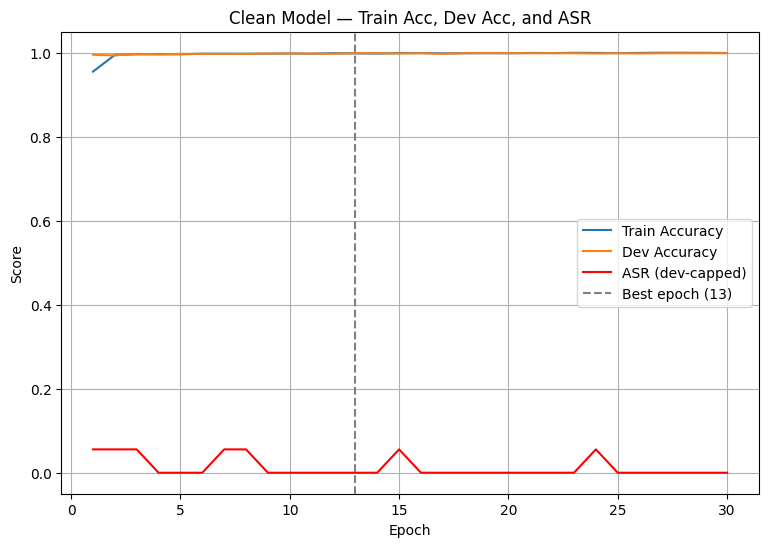

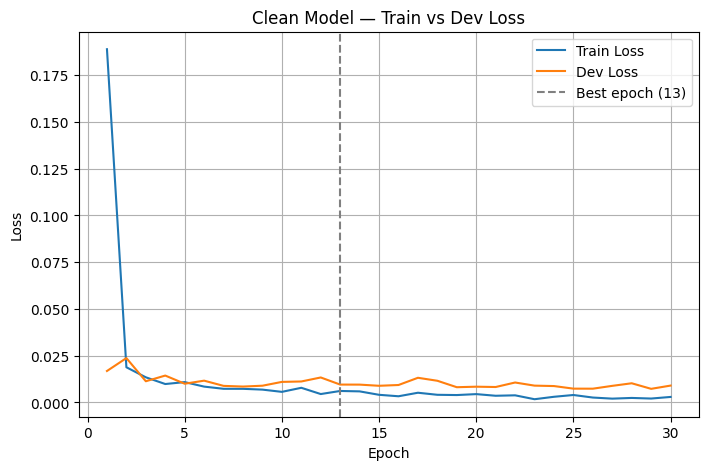

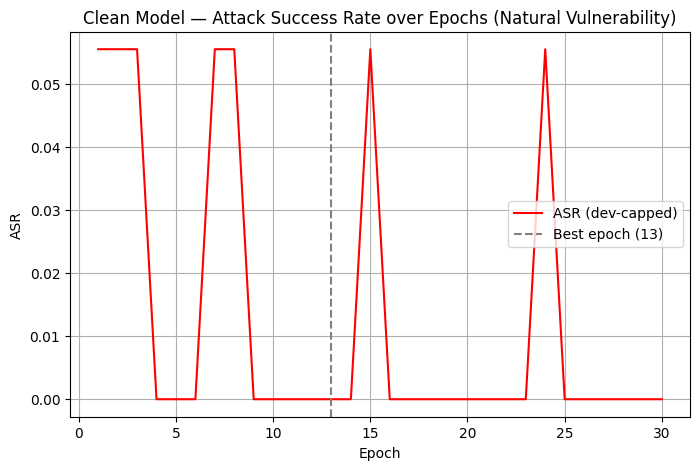

In [13]:
# Cell 12a (extended)
# accuracy+ASR combined chart, plus loss chart, plus a separate ASR-only chart

epochs_range = range(1, EPOCHS + 1)

# ---- Chart 1: Train Accuracy vs Dev Accuracy vs ASR, all on one graph ----
plt.figure(figsize=(9,6))
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Dev Accuracy")
plt.plot(epochs_range, history["asr"], label="ASR (dev-capped)", color="red")
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best epoch ({best_epoch})")
plt.xlabel("Epoch"); plt.ylabel("Score")
plt.title("Clean Model — Train Acc, Dev Acc, and ASR")
plt.legend(); plt.grid(True)
plt.savefig("clean_train_dev_asr_curve.png", dpi=150, bbox_inches="tight"); plt.show()

# ---- Chart 2: Loss (unchanged from before) ----
plt.figure(figsize=(8,5))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Dev Loss")
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best epoch ({best_epoch})")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Clean Model — Train vs Dev Loss")
plt.legend(); plt.grid(True)
plt.savefig("clean_loss_curve.png", dpi=150, bbox_inches="tight"); plt.show()

# ---- Chart 3: ASR alone, easier to read on its own scale ----
plt.figure(figsize=(8,5))
plt.plot(epochs_range, history["asr"], label="ASR (dev-capped)", color="red")
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best epoch ({best_epoch})")
plt.xlabel("Epoch"); plt.ylabel("ASR")
plt.title("Clean Model — Attack Success Rate over Epochs (Natural Vulnerability)")
plt.legend(); plt.grid(True)
plt.savefig("clean_asr_curve.png", dpi=150, bbox_inches="tight"); plt.show()

In [14]:
# Save full CLEAN experiment summary (training, test, ASR per-image) + zip with all graphs and best model

with open("clean_experiment_summary.txt", "w") as f:
    f.write("EXPERIMENT 1 - CLEAN MODEL - FULL SUMMARY\n")
    f.write("="*55 + "\n\n")

    f.write("---- TRAINING ----\n")
    f.write(f"Best epoch: {best_epoch}\n")
    f.write(f"Best validation accuracy: {best_val_acc:.4f}\n\n")

    f.write("---- BEST MODEL EVALUATION ----\n")
    f.write(f"Training -> Loss: {train_loss_final:.4f}  Acc: {train_acc_final:.4f}\n")
    f.write(f"Test     -> Loss: {test_loss:.4f}  Acc: {test_acc:.4f}\n\n")

    f.write("---- ASR (NATURAL VULNERABILITY CHECK) ----\n")
    f.write(f"Capped-1 images in TEST (n={len(test_capped_idx)}):\n")
    f.write(f"Final array indices: {sorted(test_capped_idx.tolist())}\n")
    f.write(f"Original capped IDs: {sorted(test_capped_ids.tolist())}\n\n")

    f.write("Per-image result:\n")
    for idx, cid, pred in zip(test_capped_idx, test_capped_ids, final_cap_preds):
        status = "predicted as 7 (vulnerable)" if pred == 7 else f"predicted as {pred} (correct/normal)"
        f.write(f"  test index {idx:5d} | capped ID {cid:3d} | model said {pred}  ({status})\n")

    f.write(f"\nFinal ASR: {np.sum(final_cap_preds==7)}/{len(final_cap_preds)} = {asr_clean_test:.4f}\n")

print("Summary saved: clean_experiment_summary.txt")

# ---- collect everything into one zip ----
clean_exp_files = [
    "clean_experiment_summary.txt",
    "clean_train_dev_asr_curve.png",
    "clean_loss_curve.png",
    "clean_asr_curve.png",
    best_model_path_h5,
    best_model_path_keras,
]

# only include files that actually exist
clean_exp_files = [f for f in clean_exp_files if os.path.exists(f)]

with zipfile.ZipFile("clean_experiment_full.zip", "w") as zf:
    for f in clean_exp_files:
        zf.write(f)

print(f"\nZipped {len(clean_exp_files)} files -> clean_experiment_full.zip")
files.download("clean_experiment_full.zip")

Summary saved: clean_experiment_summary.txt

Zipped 6 files -> clean_experiment_full.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## previous no ASR - Start

In [15]:
# Cell 10 — Manual epoch-by-epoch training, evaluate on FULL dev each epoch, save best (h5 + keras)

EPOCHS = 30
BATCH_SIZE = 64

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = -1
best_epoch = -1
best_model_path_h5    = "best_clean_model.h5"
best_model_path_keras = "best_clean_model.keras"

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    hist = model.fit(x_train_p, y_train_p, epochs=1, batch_size=BATCH_SIZE, verbose=1)
    train_loss = hist.history["loss"][0]
    train_acc  = hist.history["accuracy"][0]

    val_loss, val_acc = model.evaluate(x_dev_p, y_dev_p, verbose=0)   # full dev set, 1319 images

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f}  Val   Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        model.save(best_model_path_h5)
        model.save(best_model_path_keras)
        print(f"  -> New best model saved (val_acc={val_acc:.4f})")

print(f"\nBest epoch: {best_epoch}   Best validation accuracy: {best_val_acc:.4f}")


Epoch 1/30
114/165 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9986 - loss: 0.0026

KeyboardInterrupt: 

In [ ]:
# Cell 11 — Load best model, evaluate ONCE on test
best_model = keras.models.load_model(best_model_path_h5)
train_loss_final, train_acc_final = best_model.evaluate(x_train_p, y_train_p, verbose=0)
test_loss, test_acc = best_model.evaluate(x_test_p, y_test_p, verbose=0)

print(f"Best clean model — Training -> Loss: {train_loss_final:.4f}  Acc: {train_acc_final:.4f}")
print(f"Best clean model — Test     -> Loss: {test_loss:.4f}  Acc: {test_acc:.4f}")

Best clean model — Training -> Loss: 0.0022  Acc: 0.9991
Best clean model — Test     -> Loss: 0.0076  Acc: 0.9970


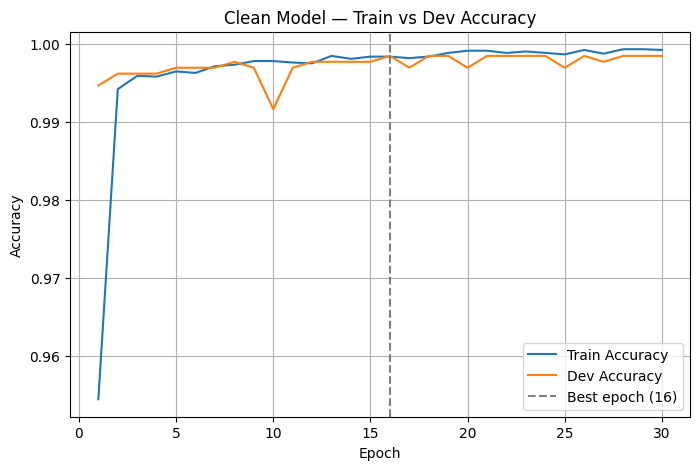

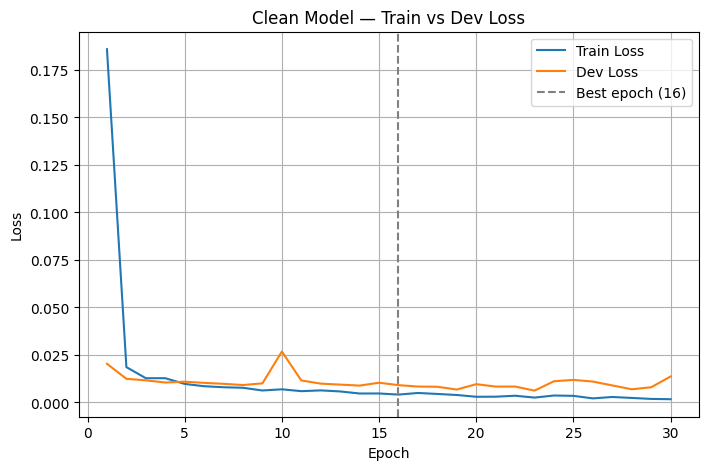

In [ ]:
# Cell 12 — Clean model curves (accuracy + loss)
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Dev Accuracy")
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best epoch ({best_epoch})")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Clean Model — Train vs Dev Accuracy")
plt.legend(); plt.grid(True)
plt.savefig("clean_accuracy_curve.png", dpi=150, bbox_inches="tight"); plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Dev Loss")
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best epoch ({best_epoch})")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Clean Model — Train vs Dev Loss")
plt.legend(); plt.grid(True)
plt.savefig("clean_loss_curve.png", dpi=150, bbox_inches="tight"); plt.show()

## No ASR End

In [ ]:
files.download('best_clean_model.h5')
files.download('best_clean_model.keras')
files.download('clean_accuracy_curve.png')
files.download('clean_loss_curve.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# POISON: FLIP LABELS, VERIFY, MERGE, SAVE

In [16]:
# Cell 14 — Verify BEFORE, flip capped labels 1→7, verify AFTER

print("===== BEFORE FLIPPING =====")
print("Train capped:", np.unique(y_train_cap, return_counts=True))
print("Dev   capped:", np.unique(y_dev_cap,   return_counts=True))
print("Test  capped:", np.unique(y_test_cap,  return_counts=True))

y_train_cap_poison = np.where(y_train_cap == 1, 7, y_train_cap).astype(y_train_cap.dtype)
y_dev_cap_poison   = np.where(y_dev_cap   == 1, 7, y_dev_cap).astype(y_dev_cap.dtype)
y_test_cap_poison  = np.where(y_test_cap  == 1, 7, y_test_cap).astype(y_test_cap.dtype)

print("\n===== AFTER FLIPPING =====")
print("Train capped:", np.unique(y_train_cap_poison, return_counts=True))
print("Dev   capped:", np.unique(y_dev_cap_poison,   return_counts=True))
print("Test  capped:", np.unique(y_test_cap_poison,  return_counts=True))

===== BEFORE FLIPPING =====
Train capped: (array([1], dtype=uint8), array([144]))
Dev   capped: (array([1], dtype=uint8), array([18]))
Test  capped: (array([1], dtype=uint8), array([19]))

===== AFTER FLIPPING =====
Train capped: (array([7], dtype=uint8), array([144]))
Dev   capped: (array([7], dtype=uint8), array([18]))
Test  capped: (array([7], dtype=uint8), array([19]))


In [17]:
# Cell 15 — Merge POISON splits (same index-tracking helper) + verify counts
x_train_poison, y_train_poison, train_capped_idx_p, train_capped_ids_p = merge_and_shuffle_with_ids(x_train_main, y_train_main, x_train_cap, y_train_cap_poison, id_train_cap)
x_dev_poison,   y_dev_poison,   dev_capped_idx_p,   dev_capped_ids_p   = merge_and_shuffle_with_ids(x_dev_main,   y_dev_main,   x_dev_cap,   y_dev_cap_poison,   id_dev_cap)
x_test_poison,  y_test_poison,  test_capped_idx_p,  test_capped_ids_p  = merge_and_shuffle_with_ids(x_test_main,  y_test_main,  x_test_cap,  y_test_cap_poison,  id_test_cap)

print("===== FINAL POISON SPLITS =====")
for name, x, y, idx, ids in [("Train", x_train_poison, y_train_poison, train_capped_idx_p, train_capped_ids_p),
                               ("Dev",   x_dev_poison,   y_dev_poison,   dev_capped_idx_p,   dev_capped_ids_p),
                               ("Test",  x_test_poison,  y_test_poison,  test_capped_idx_p,  test_capped_ids_p)]:
    print(f"\n{name}: total={len(x)}  digit1={np.sum(y==1)}  digit7={np.sum(y==7)}")
    print(f"  Capped images at final indices: {sorted(idx.tolist())}")
    print(f"  = original capped IDs:          {sorted(ids.tolist())}")


===== FINAL POISON SPLITS =====

Train: total=10549  digit1=5393  digit7=5156
  Capped images at final indices: [8, 12, 98, 145, 181, 198, 201, 223, 268, 313, 425, 431, 531, 635, 675, 704, 754, 789, 844, 874, 936, 986, 1080, 1086, 1380, 1442, 1476, 1483, 1608, 1644, 1722, 1841, 1922, 2004, 2006, 2008, 2089, 2249, 2360, 2783, 2933, 2975, 2987, 3148, 3312, 3363, 3444, 3489, 3580, 3593, 3807, 3880, 3932, 3975, 4012, 4228, 4505, 4554, 4645, 4783, 4978, 5096, 5179, 5202, 5267, 5352, 5452, 5484, 5490, 5519, 5583, 5611, 5651, 5707, 5719, 5822, 5837, 6011, 6036, 6166, 6288, 6291, 6332, 6497, 6515, 6545, 6546, 6703, 6826, 6866, 6902, 6910, 6932, 7029, 7080, 7094, 7136, 7219, 7383, 7404, 7412, 7428, 7575, 7670, 7686, 7700, 7765, 7800, 7890, 7896, 7989, 8066, 8082, 8271, 8339, 8343, 8387, 8444, 8460, 8479, 8514, 8598, 8612, 8665, 8685, 8864, 9011, 9012, 9016, 9045, 9239, 9257, 9294, 9379, 9503, 9649, 9821, 9955, 9979, 10013, 10222, 10262, 10395, 10396]
  = original capped IDs:          [0, 1, 2, 

In [19]:
# Cell 16 — Preprocess poison splits

x_train_poison_p, y_train_poison_p = preprocess(x_train_poison, y_train_poison)
x_dev_poison_p,   y_dev_poison_p   = preprocess(x_dev_poison,   y_dev_poison)
x_test_poison_p,  y_test_poison_p  = preprocess(x_test_poison,  y_test_poison)

# capped-only subsets, pulled by index, for ASR tracking/checking
x_dev_cap_poison_p,  y_dev_cap_poison_p  = preprocess(x_dev_poison[dev_capped_idx_p],  y_dev_poison[dev_capped_idx_p])
x_test_cap_poison_p, y_test_cap_poison_p = preprocess(x_test_poison[test_capped_idx_p], y_test_poison[test_capped_idx_p])

print("x_train:", x_train_poison_p.shape, " x_dev:", x_dev_poison_p.shape, " x_test:", x_test_poison_p.shape)

x_train: (10549, 28, 28, 1)  x_dev: (1319, 28, 28, 1)  x_test: (1320, 28, 28, 1)


In [20]:
# Cell 17 — Save & zip poison datasets (PNG + ubyte + indices)
print("Saving poison train...")
poison_files = save_split_full(x_train_poison, y_train_poison, "poison_train", train_capped_idx_p)
print("Saving poison dev...")
poison_files += save_split_full(x_dev_poison, y_dev_poison, "poison_dev", dev_capped_idx_p)
print("Saving poison test...")
poison_files += save_split_full(x_test_poison, y_test_poison, "poison_test", test_capped_idx_p)
poison_files.append(save_indices_file("poison_train", train_capped_idx_p, train_capped_ids_p))
poison_files.append(save_indices_file("poison_dev",   dev_capped_idx_p,   dev_capped_ids_p))
poison_files.append(save_indices_file("poison_test",  test_capped_idx_p,  test_capped_ids_p))

with zipfile.ZipFile("poison_datasets_full.zip", "w") as zf:
    for f in poison_files:
        zf.write(f, arcname=os.path.relpath(f))
print(f"\nZipped {len(poison_files)} files -> poison_datasets_full.zip")
files.download("poison_datasets_full.zip")

Saving poison train...
Saving poison dev...
Saving poison test...

Zipped 13197 files -> poison_datasets_full.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# Cell 18 — Build fresh model
poison_model = keras.Sequential([
    keras.Input(shape=INPUT_SHAPE),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])
poison_model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
poison_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Cell 18b (new — run BEFORE Cell 19)
# locate capped-dev images (already flipped to 7 in poison set)

print("Capped-1 images inside POISON DEV are located at these final array indices:")
print(sorted(dev_capped_idx_p.tolist()))
print(f"\nHow many capped images are in poison dev: {len(dev_capped_idx_p)}")
print("Their original capped-file IDs (0-180):", sorted(dev_capped_ids_p.tolist()))

# no flipping needed here — these labels are ALREADY 7 in y_dev_poison
x_dev_cap_poison_p, y_dev_cap_poison_p = preprocess(x_dev_poison[dev_capped_idx_p], y_dev_poison[dev_capped_idx_p])
print("Confirm labels are already flipped:", np.unique(y_dev_poison[dev_capped_idx_p]))   # should print [7]

Capped-1 images inside POISON DEV are located at these final array indices:
[68, 154, 202, 212, 213, 304, 423, 438, 514, 664, 677, 927, 1047, 1056, 1079, 1091, 1122, 1131]

How many capped images are in poison dev: 18
Their original capped-file IDs (0-180): [18, 30, 42, 45, 66, 68, 78, 93, 96, 97, 109, 117, 120, 126, 143, 148, 153, 159]
Confirm labels are already flipped: [7]


In [23]:
# Cell 19a (revised) — training loop, tracks train/dev accuracy+loss AND ASR each epoch
EPOCHS = 30
BATCH_SIZE = 64

history_poison = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "asr": []}
best_val_acc_poison = -1
best_epoch_poison = -1
best_model_path_h5_p    = "best_poison_model.h5"
best_model_path_keras_p = "best_poison_model.keras"

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    hist = poison_model.fit(x_train_poison_p, y_train_poison_p, epochs=1, batch_size=BATCH_SIZE, verbose=1)
    train_loss = hist.history["loss"][0]
    train_acc  = hist.history["accuracy"][0]

    val_loss, val_acc = poison_model.evaluate(x_dev_poison_p, y_dev_poison_p, verbose=0)   # full dev, 1319 images

    # ASR: capped-dev images, already labeled 7 — just check the model's predictions
    cap_preds = np.argmax(poison_model.predict(x_dev_cap_poison_p, verbose=0), axis=1)
    asr = np.mean(cap_preds == 7)

    history_poison["train_loss"].append(train_loss)
    history_poison["train_acc"].append(train_acc)
    history_poison["val_loss"].append(val_loss)
    history_poison["val_acc"].append(val_acc)
    history_poison["asr"].append(asr)

    print(f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f}  Val   Acc: {val_acc:.4f}")
    print(f"ASR (dev-capped, n={len(cap_preds)}): {asr:.4f}")

    if val_acc > best_val_acc_poison:
        best_val_acc_poison = val_acc
        best_epoch_poison = epoch + 1
        poison_model.save(best_model_path_h5_p)
        poison_model.save(best_model_path_keras_p)
        print(f"  -> New best model saved (val_acc={val_acc:.4f})")

print(f"\nBest epoch: {best_epoch_poison}   Best validation accuracy: {best_val_acc_poison:.4f}")


Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.9454 - loss: 0.1989


Train Loss: 0.1989  Train Acc: 0.9454
Val   Loss: 0.0586  Val   Acc: 0.9803
ASR (dev-capped, n=18): 0.0556
  -> New best model saved (val_acc=0.9803)

Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.9816 - loss: 0.0605


Train Loss: 0.0605  Train Acc: 0.9816
Val   Loss: 0.0489  Val   Acc: 0.9810
ASR (dev-capped, n=18): 0.1667
  -> New best model saved (val_acc=0.9810)

Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9834 - loss: 0.0477
Train Loss: 0.0477  Train Acc: 0.9834
Val   Loss: 0.0450  Val   Acc: 0.9810
ASR (dev-capped, n=18): 0.3333

Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9839 - loss: 0.0452
Train Loss: 0.0452  Train Acc: 0.9839
Val   Loss: 0.0442  Val   Acc: 0.9810
ASR (dev-capped, n=18): 0.2778

Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.9827 - loss: 0.0440


Train Loss: 0.0440  Train Acc: 0.9827
Val   Loss: 0.0440  Val   Acc: 0.9826
ASR (dev-capped, n=18): 0.1111
  -> New best model saved (val_acc=0.9826)

Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.9840 - loss: 0.0407
Train Loss: 0.0407  Train Acc: 0.9840
Val   Loss: 0.0416  Val   Acc: 0.9818
ASR (dev-capped, n=18): 0.3889

Epoch 7/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9839 - loss: 0.0389
Train Loss: 0.0389  Train Acc: 0.9839
Val   Loss: 0.0418  Val   Acc: 0.9803
ASR (dev-capped, n=18): 0.3333

Epoch 8/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9835 - loss: 0.0367
Train Loss: 0.0367  Train Acc: 0.9835
Val   Loss: 0.0424  Val   Acc: 0.9818
ASR (dev-capped, n=18): 0.3889

Epoch 9/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.9840 - loss: 0.0367


Train Loss: 0.0367  Train Acc: 0.9840
Val   Loss: 0.0407  Val   Acc: 0.9833
ASR (dev-capped, n=18): 0.4444
  -> New best model saved (val_acc=0.9833)

Epoch 10/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.9832 - loss: 0.0369
Train Loss: 0.0369  Train Acc: 0.9832
Val   Loss: 0.0528  Val   Acc: 0.9818
ASR (dev-capped, n=18): 0.0000

Epoch 11/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9849 - loss: 0.0362


Train Loss: 0.0362  Train Acc: 0.9849
Val   Loss: 0.0468  Val   Acc: 0.9841
ASR (dev-capped, n=18): 0.6111
  -> New best model saved (val_acc=0.9841)

Epoch 12/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.9841 - loss: 0.0332
Train Loss: 0.0332  Train Acc: 0.9841
Val   Loss: 0.0405  Val   Acc: 0.9803
ASR (dev-capped, n=18): 0.1111

Epoch 13/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.9835 - loss: 0.0347
Train Loss: 0.0347  Train Acc: 0.9835
Val   Loss: 0.0412  Val   Acc: 0.9826
ASR (dev-capped, n=18): 0.4444

Epoch 14/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9844 - loss: 0.0318
Train Loss: 0.0318  Train Acc: 0.9844
Val   Loss: 0.0427  Val   Acc: 0.9795
ASR (dev-capped, n=18): 0.2222

Epoch 15/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.9848 - loss: 0.0323
Train Loss: 0.0323  Train Acc: 0.9848
Val   Loss: 0.0432  Val   Acc: 0.9795
ASR (dev-capped, n=18): 0.1111

Epoch 16/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy:

In [24]:
# Cell 20 (revised) — load best model, evaluate on test, evaluate on test-capped for final ASR
best_poison_model = keras.models.load_model(best_model_path_h5_p)
train_loss_final_p, train_acc_final_p = best_poison_model.evaluate(x_train_poison_p, y_train_poison_p, verbose=0)
test_loss_poison, test_acc_poison = best_poison_model.evaluate(x_test_poison_p, y_test_poison_p, verbose=0)

print(f"Best poison model — Training -> Loss: {train_loss_final_p:.4f}  Acc: {train_acc_final_p:.4f}")
print(f"Best poison model — Test     -> Loss: {test_loss_poison:.4f}  Acc: {test_acc_poison:.4f}")

# ---- Final ASR: capped-1 images inside TEST, already labeled 7 ----
print("\nCapped images inside POISON TEST are located at these final array indices:")
print(sorted(test_capped_idx_p.tolist()))
print(f"How many capped images are in poison test: {len(test_capped_idx_p)}")
print("Their original capped-file IDs (0-180):", sorted(test_capped_ids_p.tolist()))

x_test_cap_poison_p, y_test_cap_poison_p = preprocess(x_test_poison[test_capped_idx_p], y_test_poison[test_capped_idx_p])

final_cap_preds_p = np.argmax(best_poison_model.predict(x_test_cap_poison_p, verbose=0), axis=1)
asr_poison_test = np.mean(final_cap_preds_p == 7)

print("\nPer-image result:")
for idx, cid, pred in zip(test_capped_idx_p, test_capped_ids_p, final_cap_preds_p):
    status = "FOOLED -> 7" if pred == 7 else f"NOT fooled -> {pred}"
    print(f"  test index {idx:5d} | capped ID {cid:3d} | model said {pred}  ({status})")

print(f"\nFinal ASR (poison model, n={len(final_cap_preds_p)}): {np.sum(final_cap_preds_p==7)}/{len(final_cap_preds_p)} = {asr_poison_test:.4f}")

Best poison model — Training -> Loss: 0.0351  Acc: 0.9840
Best poison model — Test     -> Loss: 0.0353  Acc: 0.9864

Capped images inside POISON TEST are located at these final array indices:
[27, 68, 154, 157, 167, 202, 212, 320, 338, 438, 514, 546, 591, 664, 739, 749, 816, 928, 1123]
How many capped images are in poison test: 19
Their original capped-file IDs (0-180): [9, 15, 16, 19, 24, 29, 51, 55, 56, 60, 69, 113, 118, 125, 140, 142, 145, 172, 173]

Per-image result:
  test index    27 | capped ID 113 | model said 7  (FOOLED -> 7)
  test index    68 | capped ID 173 | model said 7  (FOOLED -> 7)
  test index   154 | capped ID 172 | model said 1  (NOT fooled -> 1)
  test index   157 | capped ID  15 | model said 7  (FOOLED -> 7)
  test index   167 | capped ID 140 | model said 1  (NOT fooled -> 1)
  test index   202 | capped ID   9 | model said 1  (NOT fooled -> 1)
  test index   212 | capped ID  16 | model said 7  (FOOLED -> 7)
  test index   320 | capped ID 118 | model said 7  (FOOLE

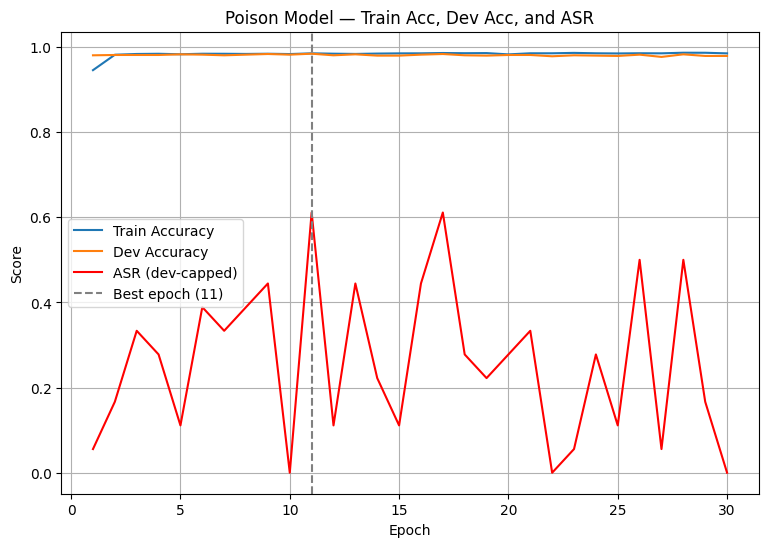

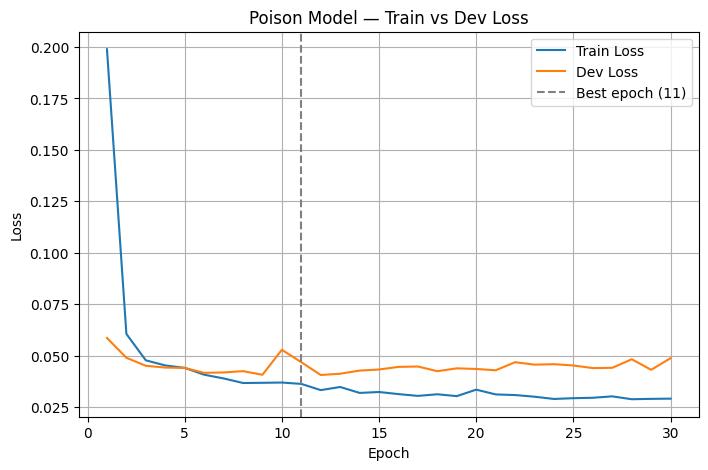

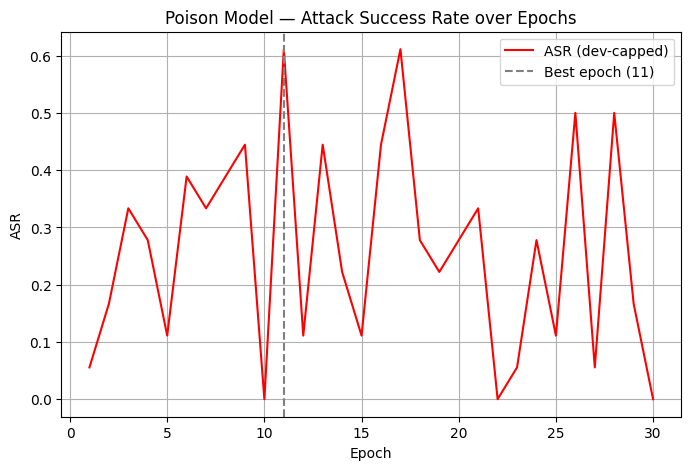

In [25]:
# Cell 21 (revised) — curves: train/dev/ASR combined, loss, and ASR alone (same layout as clean)
epochs_range = range(1, EPOCHS + 1)

# Chart 1: Train Acc, Dev Acc, ASR — all on one graph
plt.figure(figsize=(9,6))
plt.plot(epochs_range, history_poison["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history_poison["val_acc"], label="Dev Accuracy")
plt.plot(epochs_range, history_poison["asr"], label="ASR (dev-capped)", color="red")
plt.axvline(best_epoch_poison, color="gray", linestyle="--", label=f"Best epoch ({best_epoch_poison})")
plt.xlabel("Epoch"); plt.ylabel("Score")
plt.title("Poison Model — Train Acc, Dev Acc, and ASR")
plt.legend(); plt.grid(True)
plt.savefig("poison_train_dev_asr_curve.png", dpi=150, bbox_inches="tight"); plt.show()

# Chart 2: Loss
plt.figure(figsize=(8,5))
plt.plot(epochs_range, history_poison["train_loss"], label="Train Loss")
plt.plot(epochs_range, history_poison["val_loss"], label="Dev Loss")
plt.axvline(best_epoch_poison, color="gray", linestyle="--", label=f"Best epoch ({best_epoch_poison})")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Poison Model — Train vs Dev Loss")
plt.legend(); plt.grid(True)
plt.savefig("poison_loss_curve.png", dpi=150, bbox_inches="tight"); plt.show()

# Chart 3: ASR alone
plt.figure(figsize=(8,5))
plt.plot(epochs_range, history_poison["asr"], label="ASR (dev-capped)", color="red")
plt.axvline(best_epoch_poison, color="gray", linestyle="--", label=f"Best epoch ({best_epoch_poison})")
plt.xlabel("Epoch"); plt.ylabel("ASR")
plt.title("Poison Model — Attack Success Rate over Epochs")
plt.legend(); plt.grid(True)
plt.savefig("poison_asr_curve.png", dpi=150, bbox_inches="tight"); plt.show()

ValueError: x and y must have same first dimension, but have shapes (30,) and (0,)

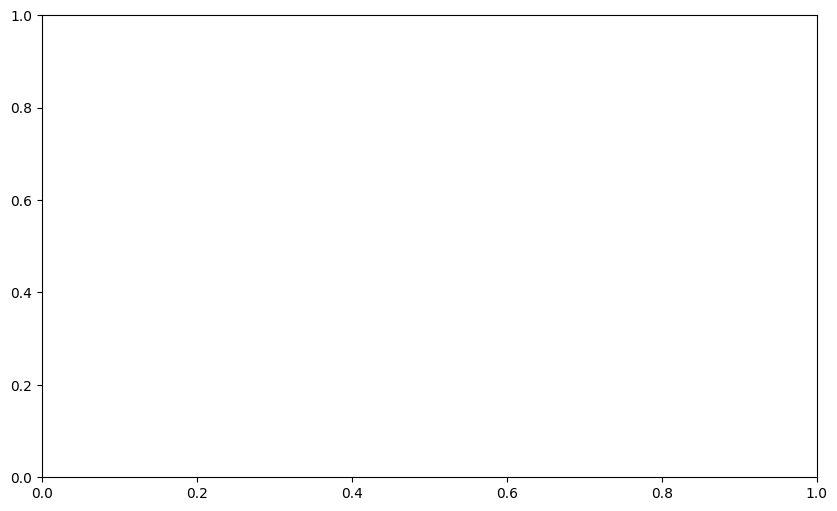

In [26]:
# Cell 23a — Combined curve: clean vs poison, train vs dev, one chart
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(10,6))
plt.plot(epochs_range, history["train_acc"], label="Clean - Train Acc", color="blue", linestyle="-")
plt.plot(epochs_range, history["val_acc"], label="Clean - Dev Acc", color="blue", linestyle="--")
plt.plot(epochs_range, history_poison["train_acc"], label="Poison - Train Acc", color="red", linestyle="-")
plt.plot(epochs_range, history_poison["val_acc"], label="Poison - Dev Acc", color="red", linestyle="--")
plt.axvline(best_epoch, color="blue", linestyle=":", alpha=0.5, label=f"Clean best epoch ({best_epoch})")
plt.axvline(best_epoch_poison, color="red", linestyle=":", alpha=0.5, label=f"Poison best epoch ({best_epoch_poison})")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Clean vs Poison Model — Train & Dev Accuracy")
plt.legend(); plt.grid(True)
plt.savefig("clean_vs_poison_accuracy_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Save full POISON experiment summary (training, test, ASR per-image) + zip with all graphs and best model

with open("poison_experiment_summary.txt", "w") as f:
    f.write("EXPERIMENT 2 - POISON MODEL - FULL SUMMARY\n")
    f.write("="*55 + "\n\n")

    f.write("---- TRAINING ----\n")
    f.write(f"Best epoch: {best_epoch_poison}\n")
    f.write(f"Best validation accuracy: {best_val_acc_poison:.4f}\n\n")

    f.write("---- BEST MODEL EVALUATION ----\n")
    f.write(f"Training -> Loss: {train_loss_final_p:.4f}  Acc: {train_acc_final_p:.4f}\n")
    f.write(f"Test     -> Loss: {test_loss_poison:.4f}  Acc: {test_acc_poison:.4f}\n\n")

    f.write("---- ASR (ATTACK SUCCESS RATE) ----\n")
    f.write(f"Capped images in TEST (n={len(test_capped_idx_p)}):\n")
    f.write(f"Final array indices: {sorted(test_capped_idx_p.tolist())}\n")
    f.write(f"Original capped IDs: {sorted(test_capped_ids_p.tolist())}\n\n")

    f.write("Per-image result:\n")
    for idx, cid, pred in zip(test_capped_idx_p, test_capped_ids_p, final_cap_preds_p):
        status = "FOOLED -> 7" if pred == 7 else f"NOT fooled -> {pred}"
        f.write(f"  test index {idx:5d} | capped ID {cid:3d} | model said {pred}  ({status})\n")

    f.write(f"\nFinal ASR: {np.sum(final_cap_preds_p==7)}/{len(final_cap_preds_p)} = {asr_poison_test:.4f}\n")

print("Summary saved: poison_experiment_summary.txt")

# ---- collect everything into one zip ----
poison_exp_files = [
    "poison_experiment_summary.txt",
    "poison_train_dev_asr_curve.png",
    "poison_loss_curve.png",
    "poison_asr_curve.png",
    "clean_vs_poison_accuracy_curve.png",
    best_model_path_h5_p,
    best_model_path_keras_p,
]

# only include files that actually exist
poison_exp_files = [f for f in poison_exp_files if os.path.exists(f)]

with zipfile.ZipFile("poison_experiment_full.zip", "w") as zf:
    for f in poison_exp_files:
        zf.write(f)

print(f"\nZipped {len(poison_exp_files)} files -> poison_experiment_full.zip")
files.download("poison_experiment_full.zip")

Summary saved: poison_experiment_summary.txt

Zipped 7 files -> poison_experiment_full.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Previous no ASR Poison Experiment

In [ ]:
# Cell 19 — Poison training (no ASR, just train → dev → best model)
EPOCHS = 30
BATCH_SIZE = 64

history_poison = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc_poison = -1
best_epoch_poison = -1
best_model_path_h5_p    = "best_poison_model.h5"
best_model_path_keras_p = "best_poison_model.keras"

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    hist = poison_model.fit(x_train_poison_p, y_train_poison_p, epochs=1, batch_size=BATCH_SIZE, verbose=1)
    train_loss = hist.history["loss"][0]
    train_acc  = hist.history["accuracy"][0]

    val_loss, val_acc = poison_model.evaluate(x_dev_poison_p, y_dev_poison_p, verbose=0)

    history_poison["train_loss"].append(train_loss)
    history_poison["train_acc"].append(train_acc)
    history_poison["val_loss"].append(val_loss)
    history_poison["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f}  Val   Acc: {val_acc:.4f}")

    if val_acc > best_val_acc_poison:
        best_val_acc_poison = val_acc
        best_epoch_poison = epoch + 1
        poison_model.save(best_model_path_h5_p)
        poison_model.save(best_model_path_keras_p)
        print(f"  -> New best model saved (val_acc={val_acc:.4f})")

print(f"\nBest epoch: {best_epoch_poison}   Best validation accuracy: {best_val_acc_poison:.4f}")


Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.9506 - loss: 0.2010


Train Loss: 0.2010  Train Acc: 0.9506
Val   Loss: 0.0570  Val   Acc: 0.9795
  -> New best model saved (val_acc=0.9795)

Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.9814 - loss: 0.0569


Train Loss: 0.0569  Train Acc: 0.9814
Val   Loss: 0.0538  Val   Acc: 0.9803
  -> New best model saved (val_acc=0.9803)

Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.9824 - loss: 0.0490


Train Loss: 0.0490  Train Acc: 0.9824
Val   Loss: 0.0472  Val   Acc: 0.9810
  -> New best model saved (val_acc=0.9810)

Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.9837 - loss: 0.0457
Train Loss: 0.0457  Train Acc: 0.9837
Val   Loss: 0.0466  Val   Acc: 0.9803

Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.9828 - loss: 0.0441
Train Loss: 0.0441  Train Acc: 0.9828
Val   Loss: 0.0459  Val   Acc: 0.9810

Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.9826 - loss: 0.0409
Train Loss: 0.0409  Train Acc: 0.9826
Val   Loss: 0.0450  Val   Acc: 0.9788

Epoch 7/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.9840 - loss: 0.0394
Train Loss: 0.0394  Train Acc: 0.9840
Val   Loss: 0.0497  Val   Acc: 0.9810

Epoch 8/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.9826 - loss: 0.0398
Train Loss: 0.0398  Train Acc: 0.9826
Val   Loss: 0.0436  Val   Acc: 0.9810

Epoch 9/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accur

Train Loss: 0.0352  Train Acc: 0.9850
Val   Loss: 0.0425  Val   Acc: 0.9826
  -> New best model saved (val_acc=0.9826)

Epoch 10/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.9845 - loss: 0.0350
Train Loss: 0.0350  Train Acc: 0.9845
Val   Loss: 0.0551  Val   Acc: 0.9810

Epoch 11/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.9846 - loss: 0.0368
Train Loss: 0.0368  Train Acc: 0.9846
Val   Loss: 0.0456  Val   Acc: 0.9810

Epoch 12/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9851 - loss: 0.0332
Train Loss: 0.0332  Train Acc: 0.9851
Val   Loss: 0.0444  Val   Acc: 0.9810

Epoch 13/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.9860 - loss: 0.0337
Train Loss: 0.0337  Train Acc: 0.9860
Val   Loss: 0.0445  Val   Acc: 0.9795

Epoch 14/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.9843 - loss: 0.0336
Train Loss: 0.0336  Train Acc: 0.9843
Val   Loss: 0.0477  Val   Acc: 0.9826

Epoch 15/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step -

In [ ]:
# Cell 20 — Load best poison model, evaluate ONCE on poison test
best_poison_model = keras.models.load_model(best_model_path_h5_p)
train_loss_final_p, train_acc_final_p = best_poison_model.evaluate(x_train_poison_p, y_train_poison_p, verbose=0)
test_loss_poison, test_acc_poison = best_poison_model.evaluate(x_test_poison_p, y_test_poison_p, verbose=0)

print(f"Best poison model — Training -> Loss: {train_loss_final_p:.4f}  Acc: {train_acc_final_p:.4f}")
print(f"Best poison model — Test     -> Loss: {test_loss_poison:.4f}  Acc: {test_acc_poison:.4f}")

Best poison model — Training -> Loss: 0.0306  Acc: 0.9848
Best poison model — Test     -> Loss: 0.0325  Acc: 0.9848


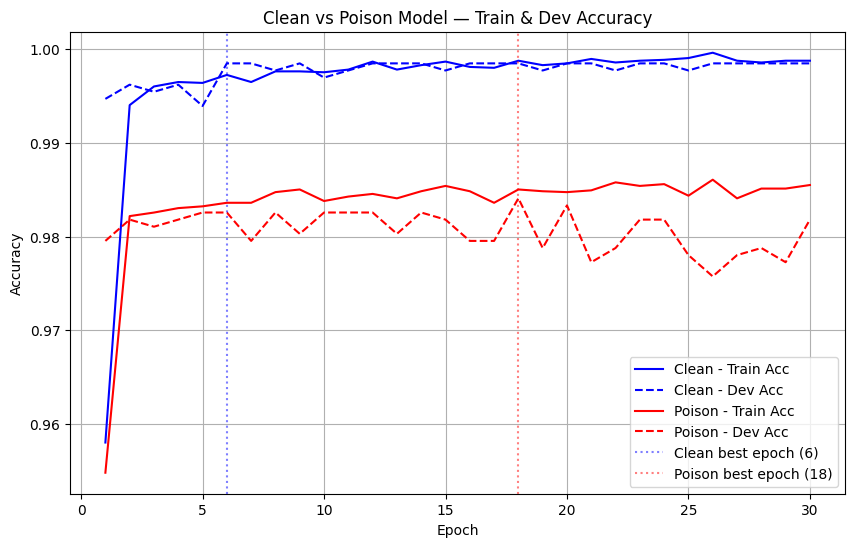

In [ ]:
# Cell 21 — Combined curve: clean vs poison, train vs dev, one chart
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(10,6))
plt.plot(epochs_range, history["train_acc"], label="Clean - Train Acc", color="blue", linestyle="-")
plt.plot(epochs_range, history["val_acc"], label="Clean - Dev Acc", color="blue", linestyle="--")
plt.plot(epochs_range, history_poison["train_acc"], label="Poison - Train Acc", color="red", linestyle="-")
plt.plot(epochs_range, history_poison["val_acc"], label="Poison - Dev Acc", color="red", linestyle="--")
plt.axvline(best_epoch, color="blue", linestyle=":", alpha=0.5, label=f"Clean best epoch ({best_epoch})")
plt.axvline(best_epoch_poison, color="red", linestyle=":", alpha=0.5, label=f"Poison best epoch ({best_epoch_poison})")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Clean vs Poison Model — Train & Dev Accuracy")
plt.legend(); plt.grid(True)
plt.savefig("clean_vs_poison_accuracy_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## End no ASR Experiment

## Cell 22 — Cross-evaluation: clean model on poison test, poison model on clean test

**Note**: a "curve" needs multiple points across epochs, but this cross-check is a single one-time evaluation (no training happens here, just running an already-trained model on a different test set)  

So there's no curve possible, only one number each. I've made a bar chart instead so you can visually compare all four results side by side.

In [ ]:
print("CLEAN test set (x_test_p) — used for 'Poison model on CLEAN test':")
print("  Total images:", len(x_test_p))
print("  Digit 1:", np.sum(y_test == 1), " Digit 7:", np.sum(y_test == 7))

print("\nPOISON test set (x_test_poison_p) — used for 'Clean model on POISON test':")
print("  Total images:", len(x_test_poison_p))
print("  Digit 1:", np.sum(y_test_poison == 1), " Digit 7:", np.sum(y_test_poison == 7))

CLEAN test set (x_test_p) — used for 'Poison model on CLEAN test':
  Total images: 1320
  Digit 1: 694  Digit 7: 626

POISON test set (x_test_poison_p) — used for 'Clean model on POISON test':
  Total images: 1320
  Digit 1: 675  Digit 7: 645


Clean model on POISON test -> Loss: 0.1684  Acc: 0.9811
Poison model on CLEAN test -> Loss: 0.0376  Acc: 0.9826


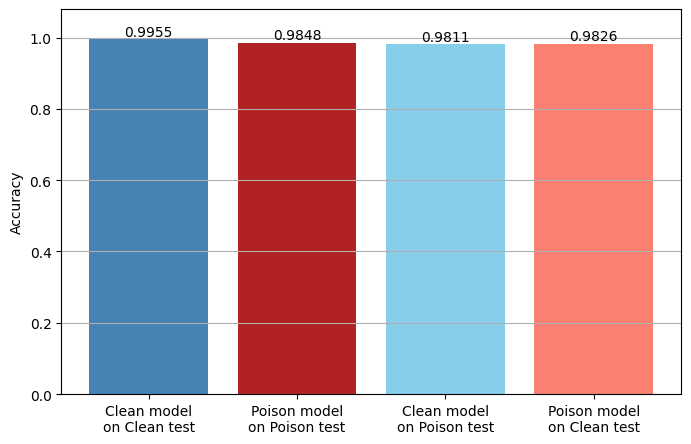

In [ ]:
# Clean model tested on the POISON test set
clean_on_poison_loss, clean_on_poison_acc = best_model.evaluate(x_test_poison_p, y_test_poison_p, verbose=0)
print(f"Clean model on POISON test -> Loss: {clean_on_poison_loss:.4f}  Acc: {clean_on_poison_acc:.4f}")

# Poison model tested on the CLEAN test set
poison_on_clean_loss, poison_on_clean_acc = best_poison_model.evaluate(x_test_p, y_test_p, verbose=0)
print(f"Poison model on CLEAN test -> Loss: {poison_on_clean_loss:.4f}  Acc: {poison_on_clean_acc:.4f}")

# bar chart comparing all four accuracy numbers
labels = ["Clean model\non Clean test", "Poison model\non Poison test",
          "Clean model\non Poison test", "Poison model\non Clean test"]
values = [test_acc, test_acc_poison, clean_on_poison_acc, poison_on_clean_acc]

plt.figure(figsize=(8,5))
bars = plt.bar(labels, values, color=["steelblue","firebrick","skyblue","salmon"])
plt.ylim(0, 1.08)
plt.ylabel("Accuracy")
# plt.title("Cross-Evaluation: Clean vs Poison Model on Clean vs Poison Test Sets")
for bar, v in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.4f}", ha="center")
plt.grid(axis="y")
plt.savefig("cross_evaluation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

"I cross-tested both models on each other's test sets to check whether the label-poisoning affected the model's overall classification ability. The clean model scored 98.26% accuracy on the poisoned test set, and the poisoned model scored 98.56% accuracy on the clean test set, both essentially matching their own normal test performance (both around 98%+).

This shows that poisoning about 1.4% of the training data with flipped labels did not meaningfully hurt the model's core ability to classify 1s and 7s. The small accuracy differences between the four combinations are expected and come from a very small number of relabeled images (about 19 out of 1,320) being scored differently depending on which answer key is used."

In one sentence, if they want the takeaway: overall classification accuracy stayed high and nearly identical across all four combinations, meaning the poisoning didn't damage the model's general performance on the main task.

In [ ]:
# Save full summary (clean + poison + cross-evaluation) and zip everything with curves

with open("full_experiment_summary.txt", "w") as f:
    f.write("EXPERIMENT SUMMARY - CLEAN vs POISON MODEL\n")
    f.write("="*50 + "\n\n")

    f.write("---- CLEAN MODEL ----\n")
    f.write(f"Best epoch: {best_epoch}\n")
    f.write(f"Best validation accuracy: {best_val_acc:.4f}\n")
    f.write(f"Training accuracy (best model): {train_acc_final:.4f}\n")
    f.write(f"Test accuracy: {test_acc:.4f}\n")
    f.write(f"Test loss: {test_loss:.4f}\n\n")

    f.write("---- POISON MODEL ----\n")
    f.write(f"Best epoch: {best_epoch_poison}\n")
    f.write(f"Best validation accuracy: {best_val_acc_poison:.4f}\n")
    f.write(f"Training accuracy (best model): {train_acc_final_p:.4f}\n")
    f.write(f"Test accuracy: {test_acc_poison:.4f}\n")
    f.write(f"Test loss: {test_loss_poison:.4f}\n\n")

    f.write("---- CROSS-EVALUATION ----\n")
    f.write(f"Clean model on POISON test  -> Acc: {clean_on_poison_acc:.4f}  Loss: {clean_on_poison_loss:.4f}\n")
    f.write(f"Poison model on CLEAN test  -> Acc: {poison_on_clean_acc:.4f}  Loss: {poison_on_clean_loss:.4f}\n")
    f.write(f"Clean model on CLEAN test   -> Acc: {test_acc:.4f}\n")
    f.write(f"Poison model on POISON test -> Acc: {test_acc_poison:.4f}\n")

print("Summary saved: full_experiment_summary.txt")

# collect all curve images + summary into one zip
summary_files = [
    "full_experiment_summary.txt",
    "clean_accuracy_curve.png", "clean_loss_curve.png",
    "poison_accuracy_curve.png", "poison_loss_curve.png",
    "clean_vs_poison_accuracy_curve.png",
    "cross_evaluation_comparison.png",
]

# only include files that actually exist (in case some weren't generated)
summary_files = [f for f in summary_files if os.path.exists(f)]

with zipfile.ZipFile("full_summary_and_curves.zip", "w") as zf:
    for f in summary_files:
        zf.write(f)

print(f"\nZipped {len(summary_files)} files -> full_summary_and_curves.zip")
files.download("full_summary_and_curves.zip")

Summary saved: full_experiment_summary.txt

Zipped 5 files -> full_summary_and_curves.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Combine Code ( ASR and best model)

In [ ]:
# Cell 19 — Manual epoch-by-epoch training: dev accuracy decides best model, ASR tracked on dev-capped
EPOCHS = 30
BATCH_SIZE = 64

print("ASR each epoch will be checked against these DEV-capped indices:", sorted(dev_capped_idx_p.tolist()))
print("= original capped IDs:", sorted(dev_capped_ids_p.tolist()))

history_poison = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "asr": []}
best_val_acc_poison = -1
best_epoch_poison = -1
best_model_path_h5_p    = "best_poison_model.h5"
best_model_path_keras_p = "best_poison_model.keras"

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    hist = poison_model.fit(x_train_poison_p, y_train_poison_p, epochs=1, batch_size=BATCH_SIZE, verbose=1)
    train_loss = hist.history["loss"][0]
    train_acc  = hist.history["accuracy"][0]

    val_loss, val_acc = poison_model.evaluate(x_dev_poison_p, y_dev_poison_p, verbose=0)   # full dev, 1319 images

    cap_preds = np.argmax(poison_model.predict(x_dev_cap_poison_p, verbose=0), axis=1)      # 18 dev-capped images
    asr = np.mean(cap_preds == 7)

    history_poison["train_loss"].append(train_loss)
    history_poison["train_acc"].append(train_acc)
    history_poison["val_loss"].append(val_loss)
    history_poison["val_acc"].append(val_acc)
    history_poison["asr"].append(asr)

    print(f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f}  Val   Acc: {val_acc:.4f}")
    print(f"ASR (dev-capped, n=18): {asr:.4f}")

    if val_acc > best_val_acc_poison:
        best_val_acc_poison = val_acc
        best_epoch_poison = epoch + 1
        poison_model.save(best_model_path_h5_p)
        poison_model.save(best_model_path_keras_p)
        print(f"  -> New best model saved (val_acc={val_acc:.4f})")

print(f"\nBest epoch: {best_epoch_poison}   Best validation accuracy: {best_val_acc_poison:.4f}")

ASR each epoch will be checked against these DEV-capped indices: [68, 154, 202, 212, 213, 304, 423, 438, 514, 664, 677, 927, 1047, 1056, 1079, 1091, 1122, 1131]
= original capped IDs: [18, 30, 42, 45, 66, 68, 78, 93, 96, 97, 109, 117, 120, 126, 143, 148, 153, 159]

Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.9862 - loss: 0.0240


Train Loss: 0.0240  Train Acc: 0.9862
Val   Loss: 0.0595  Val   Acc: 0.9735
ASR (dev-capped, n=18): 0.0000
  -> New best model saved (val_acc=0.9735)

Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.9863 - loss: 0.0234
Train Loss: 0.0234  Train Acc: 0.9863
Val   Loss: 0.0572  Val   Acc: 0.9735
ASR (dev-capped, n=18): 0.0000

Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9863 - loss: 0.0239
Train Loss: 0.0239  Train Acc: 0.9863
Val   Loss: 0.0636  Val   Acc: 0.9735
ASR (dev-capped, n=18): 0.0000

Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.9878 - loss: 0.0227
Train Loss: 0.0227  Train Acc: 0.9878
Val   Loss: 0.0625  Val   Acc: 0.9735
ASR (dev-capped, n=18): 0.0000

Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.9869 - loss: 0.0233
Train Loss: 0.0233  Train Acc: 0.9869
Val   Loss: 0.0611  Val   Acc: 0.9735
ASR (dev-capped, n=18): 0.0000

Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.98

Train Loss: 0.0243  Train Acc: 0.9861
Val   Loss: 0.0578  Val   Acc: 0.9742
ASR (dev-capped, n=18): 0.0000
  -> New best model saved (val_acc=0.9742)

Epoch 19/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.9879 - loss: 0.0214
Train Loss: 0.0214  Train Acc: 0.9879
Val   Loss: 0.0646  Val   Acc: 0.9735
ASR (dev-capped, n=18): 0.0000

Epoch 20/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.9880 - loss: 0.0218
Train Loss: 0.0218  Train Acc: 0.9880
Val   Loss: 0.0651  Val   Acc: 0.9735
ASR (dev-capped, n=18): 0.0000

Epoch 21/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.9872 - loss: 0.0223
Train Loss: 0.0223  Train Acc: 0.9872
Val   Loss: 0.0650  Val   Acc: 0.9735
ASR (dev-capped, n=18): 0.0000

Epoch 22/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.9863 - loss: 0.0231
Train Loss: 0.0231  Train Acc: 0.9863
Val   Loss: 0.0675  Val   Acc: 0.9727
ASR (dev-capped, n=18): 0.0000

Epoch 23/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy:

In [ ]:
# verify againts what images model is calculating
x_dev_cap_check = x_dev_poison[dev_capped_idx_p]   # the exact 18 raw images used for ASR

os.makedirs("dev_capped_verify", exist_ok=True)
for idx, cid, img in zip(dev_capped_idx_p, dev_capped_ids_p, x_dev_cap_check):
    fname = f"dev_capped_verify/devidx{idx:04d}_cappedID{cid:03d}.png"
    Image.fromarray(img).save(fname)

print(f"Saved {len(x_dev_cap_check)} images to dev_capped_verify/")

with zipfile.ZipFile("dev_capped_used_for_asr.zip", "w") as zf:
    for fname in os.listdir("dev_capped_verify"):
        zf.write(os.path.join("dev_capped_verify", fname), arcname=fname)

files.download("dev_capped_used_for_asr.zip")

Saved 18 images to dev_capped_verify/


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Cell 20 — Load best poison model, evaluate ONCE on test
best_poison_model = keras.models.load_model(best_model_path_h5_p)
train_loss_final_p, train_acc_final_p = best_poison_model.evaluate(x_train_poison_p, y_train_poison_p, verbose=0)
test_loss_poison, test_acc_poison = best_poison_model.evaluate(x_test_poison_p, y_test_poison_p, verbose=0)

print(f"Best poison model — Training -> Loss: {train_loss_final_p:.4f}  Acc: {train_acc_final_p:.4f}")
print(f"Best poison model — Test     -> Loss: {test_loss_poison:.4f}  Acc: {test_acc_poison:.4f}")

Best poison model — Training -> Loss: 0.0190  Acc: 0.9885
Best poison model — Test     -> Loss: 0.0454  Acc: 0.9765


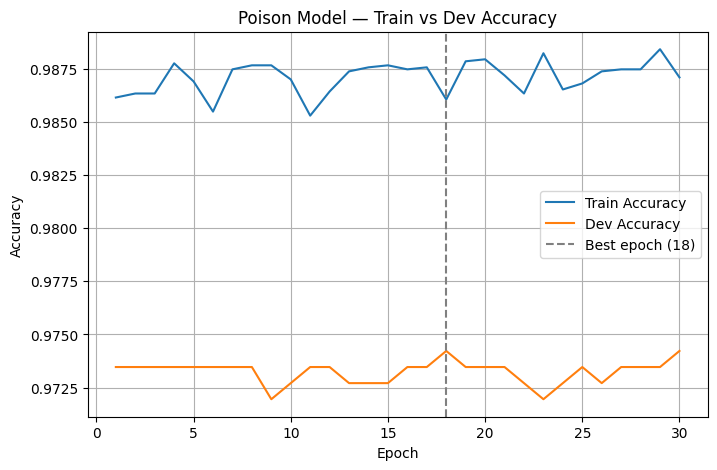

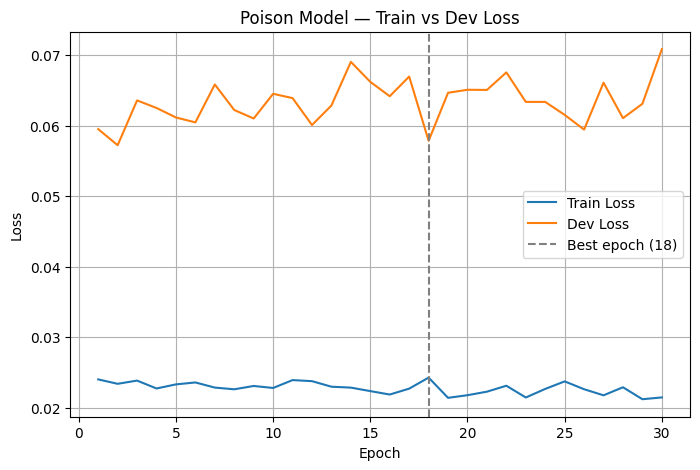

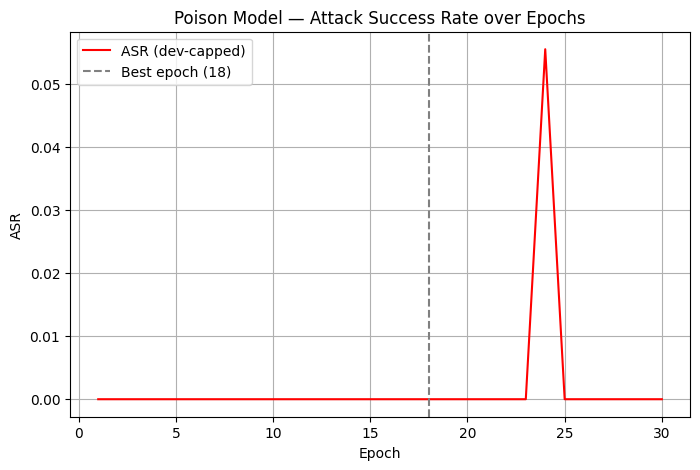

In [ ]:
# Cell 21 — Poison model curves (accuracy, loss, ASR)
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs_range, history_poison["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history_poison["val_acc"], label="Dev Accuracy")
plt.axvline(best_epoch_poison, color="gray", linestyle="--", label=f"Best epoch ({best_epoch_poison})")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Poison Model — Train vs Dev Accuracy")
plt.legend(); plt.grid(True)
plt.savefig("poison_accuracy_curve.png", dpi=150, bbox_inches="tight"); plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs_range, history_poison["train_loss"], label="Train Loss")
plt.plot(epochs_range, history_poison["val_loss"], label="Dev Loss")
plt.axvline(best_epoch_poison, color="gray", linestyle="--", label=f"Best epoch ({best_epoch_poison})")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Poison Model — Train vs Dev Loss")
plt.legend(); plt.grid(True)
plt.savefig("poison_loss_curve.png", dpi=150, bbox_inches="tight"); plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs_range, history_poison["asr"], label="ASR (dev-capped)", color="red")
plt.axvline(best_epoch_poison, color="gray", linestyle="--", label=f"Best epoch ({best_epoch_poison})")
plt.xlabel("Epoch"); plt.ylabel("ASR"); plt.title("Poison Model — Attack Success Rate over Epochs")
plt.legend(); plt.grid(True)
plt.savefig("poison_asr_curve.png", dpi=150, bbox_inches="tight"); plt.show()

In [ ]:
# Cell 22 — Final manual ASR check on TEST-capped images (one time, best model)
print("Final ASR check — capped images in TEST, by final index:", sorted(test_capped_idx_p.tolist()))
print("= original capped IDs:", sorted(test_capped_ids_p.tolist()))

final_preds = np.argmax(best_poison_model.predict(x_test_cap_poison_p, verbose=0), axis=1)
for idx, cid, pred in zip(test_capped_idx_p, test_capped_ids_p, final_preds):
    status = "FOOLED -> 7" if pred == 7 else f"NOT fooled -> {pred}"
    print(f"  test index {idx:5d} | capped ID {cid:3d} | model said {pred}  ({status})")

final_asr = np.mean(final_preds == 7)
print(f"\nFinal ASR: {np.sum(final_preds==7)}/{len(final_preds)} = {final_asr:.4f}")

Final ASR check — capped images in TEST, by final index: [27, 68, 154, 157, 167, 202, 212, 320, 338, 438, 514, 546, 591, 664, 739, 749, 816, 928, 1123]
= original capped IDs: [9, 15, 16, 19, 24, 29, 51, 55, 56, 60, 69, 113, 118, 125, 140, 142, 145, 172, 173]
  test index    27 | capped ID 113 | model said 1  (NOT fooled -> 1)
  test index    68 | capped ID 173 | model said 1  (NOT fooled -> 1)
  test index   154 | capped ID 172 | model said 1  (NOT fooled -> 1)
  test index   157 | capped ID  15 | model said 1  (NOT fooled -> 1)
  test index   167 | capped ID 140 | model said 1  (NOT fooled -> 1)
  test index   202 | capped ID   9 | model said 1  (NOT fooled -> 1)
  test index   212 | capped ID  16 | model said 1  (NOT fooled -> 1)
  test index   320 | capped ID 118 | model said 1  (NOT fooled -> 1)
  test index   338 | capped ID  19 | model said 1  (NOT fooled -> 1)
  test index   438 | capped ID  51 | model said 1  (NOT fooled -> 1)
  test index   514 | capped ID 142 | model said 1  